Prepare customer data for modeling using cleaning, feature  engineering, and EDA.  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel(r"C:\Users\kshal\Downloads\telecom_customer_churn.xlsx")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

In [4]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [5]:
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [6]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                  

In [7]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [9]:
df = df.drop_duplicates()

In [10]:
df.head(20)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.60,593.30,0.00,0,381.51,974.81,Stayed,Competitor,Competitor had better devices
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.00,542.40,38.33,10,96.21,610.28,Stayed,Competitor,Competitor had better devices
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.90,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.00,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.90,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
5,0013-MHZWF,Female,23,No,3,Midpines,95345,37.581496,-119.972762,0,...,Credit Card,69.40,571.45,0.00,0,150.93,722.38,Stayed,Competitor,Competitor had better devices
6,0013-SMEOE,Female,67,Yes,0,Lompoc,93437,34.757477,-120.550507,1,...,Bank Withdrawal,109.70,7904.25,0.00,0,707.16,8611.41,Stayed,Competitor,Competitor had better devices
7,0014-BMAQU,Male,52,Yes,0,Napa,94558,38.489789,-122.270110,8,...,Credit Card,84.65,5377.80,0.00,20,816.48,6214.28,Stayed,Competitor,Competitor had better devices
8,0015-UOCOJ,Female,68,No,0,Simi Valley,93063,34.296813,-118.685703,0,...,Bank Withdrawal,48.20,340.35,0.00,0,73.71,414.06,Stayed,Competitor,Competitor had better devices
9,0016-QLJIS,Female,43,Yes,1,Sheridan,95681,38.984756,-121.345074,3,...,Credit Card,90.45,5957.90,0.00,0,1849.90,7807.80,Stayed,Competitor,Competitor had better devices


In [12]:
bins = [0, 12, 24, 48, 60, 100]
labels = ['0-12', '13-24', '25-48', '49-60', '60+']

df['TenureGroup'] = pd.cut(df['Tenure in Months'], bins=bins, labels=labels)

In [15]:
df['AvgMonthlySpend'] = df['Total Charges'] / df['Tenure in Months'].replace(0, 1)

In [16]:
yes_no_cols = []

for col in df.columns:
    if set(df[col].dropna().unique()) == {'Yes', 'No'}:
        yes_no_cols.append(col)

print(yes_no_cols)

['Married', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Paperless Billing']


In [17]:
for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [18]:
df = pd.get_dummies(df, columns=['Contract', 'Internet Service'], drop_first=True)

In [19]:
df.head(20)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,TenureGroup,AvgMonthlySpend,Contract_One Year,Contract_Two Year,Internet Service_1
0,0002-ORFBO,Female,37,1,0,Frazier Park,93225,34.827662,-118.999073,2,...,381.51,974.81,Stayed,Competitor,Competitor had better devices,0-12,65.922222,True,False,True
1,0003-MKNFE,Male,46,0,0,Glendale,91206,34.162515,-118.203869,0,...,96.21,610.28,Stayed,Competitor,Competitor had better devices,0-12,60.266667,False,False,True
2,0004-TLHLJ,Male,50,0,0,Costa Mesa,92627,33.645672,-117.922613,0,...,134.60,415.45,Churned,Competitor,Competitor had better devices,0-12,70.212500,False,False,True
3,0011-IGKFF,Male,78,1,0,Martinez,94553,38.014457,-122.115432,1,...,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,13-24,95.219231,False,False,True
4,0013-EXCHZ,Female,75,1,0,Camarillo,93010,34.227846,-119.079903,3,...,22.14,289.54,Churned,Dissatisfaction,Network reliability,0-12,89.133333,False,False,True
5,0013-MHZWF,Female,23,0,3,Midpines,95345,37.581496,-119.972762,0,...,150.93,722.38,Stayed,Competitor,Competitor had better devices,0-12,63.494444,False,False,True
6,0013-SMEOE,Female,67,1,0,Lompoc,93437,34.757477,-120.550507,1,...,707.16,8611.41,Stayed,Competitor,Competitor had better devices,60+,111.327465,False,True,True
7,0014-BMAQU,Male,52,1,0,Napa,94558,38.489789,-122.270110,8,...,816.48,6214.28,Stayed,Competitor,Competitor had better devices,60+,85.361905,False,True,True
8,0015-UOCOJ,Female,68,0,0,Simi Valley,93063,34.296813,-118.685703,0,...,73.71,414.06,Stayed,Competitor,Competitor had better devices,0-12,48.621429,False,True,True
9,0016-QLJIS,Female,43,1,1,Sheridan,95681,38.984756,-121.345074,3,...,1849.90,7807.80,Stayed,Competitor,Competitor had better devices,60+,91.660000,False,True,True


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Customer ID                        7043 non-null   object  
 1   Gender                             7043 non-null   object  
 2   Age                                7043 non-null   int64   
 3   Married                            7043 non-null   int64   
 4   Number of Dependents               7043 non-null   int64   
 5   City                               7043 non-null   object  
 6   Zip Code                           7043 non-null   int64   
 7   Latitude                           7043 non-null   float64 
 8   Longitude                          7043 non-null   float64 
 9   Number of Referrals                7043 non-null   int64   
 10  Tenure in Months                   7043 non-null   int64   
 11  Offer                              7043 non

In [21]:
df.describe()

,Age,Married,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,...,Streaming Music,Unlimited Data,Paperless Billing,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,AvgMonthlySpend
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.483033,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,0.903166,25.446612,...,0.353259,0.890388,0.592219,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056,64.762914
std,16.750352,0.499748,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,0.295752,13.495466,...,0.478016,0.312428,0.491457,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542,30.189784
min,19.000000,0.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,0.000000,1.010000,...,0.000000,0.000000,0.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000,13.775000
25%,32.000000,0.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,1.000000,14.455000,...,0.000000,1.000000,0.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000,35.935156
50%,46.000000,0.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,1.000000,25.690000,...,0.000000,1.000000,1.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000,70.337500
75%,60.000000,1.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,1.000000,36.395000,...,1.000000,1.000000,1.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,90.174158
max,80.000000,1.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,1.000000,49.990000,...,1.000000,1.000000,1.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,121.400000


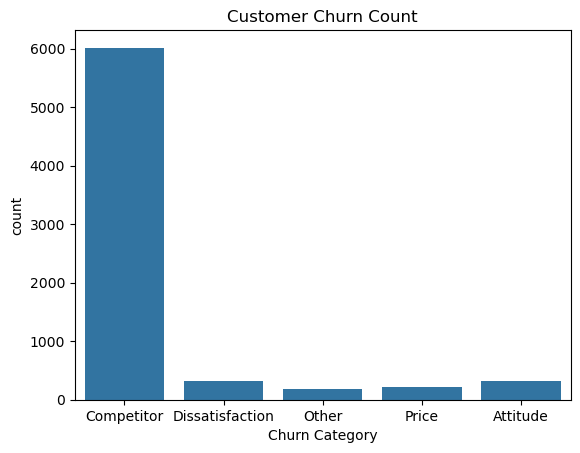

In [46]:
sns.countplot(x = 'Churn Category', data = df)
plt.title("Customer Churn Count")
plt.savefig("ChurnDistribution")
plt.show()

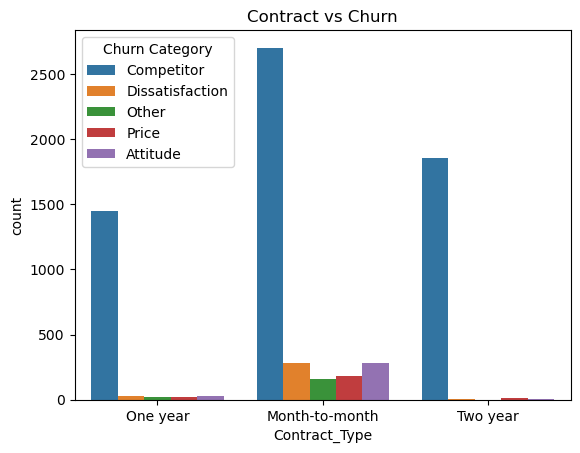

In [29]:
df['Contract_Type'] = 'Month-to-month'
df.loc[df['Contract_One Year'] == 1, 'Contract_Type'] = 'One year'
df.loc[df['Contract_Two Year'] == 1, 'Contract_Type'] = 'Two year'

sns.countplot(x='Contract_Type', hue='Churn Category', data=df)
plt.title("Contract vs Churn")
plt.show()

###Insight:

Customers with Month-to-Month contracts have higher churn.
Long-term contracts (1 year / 2 year) have lower churn.
"Long-term contracts improve customer retention."

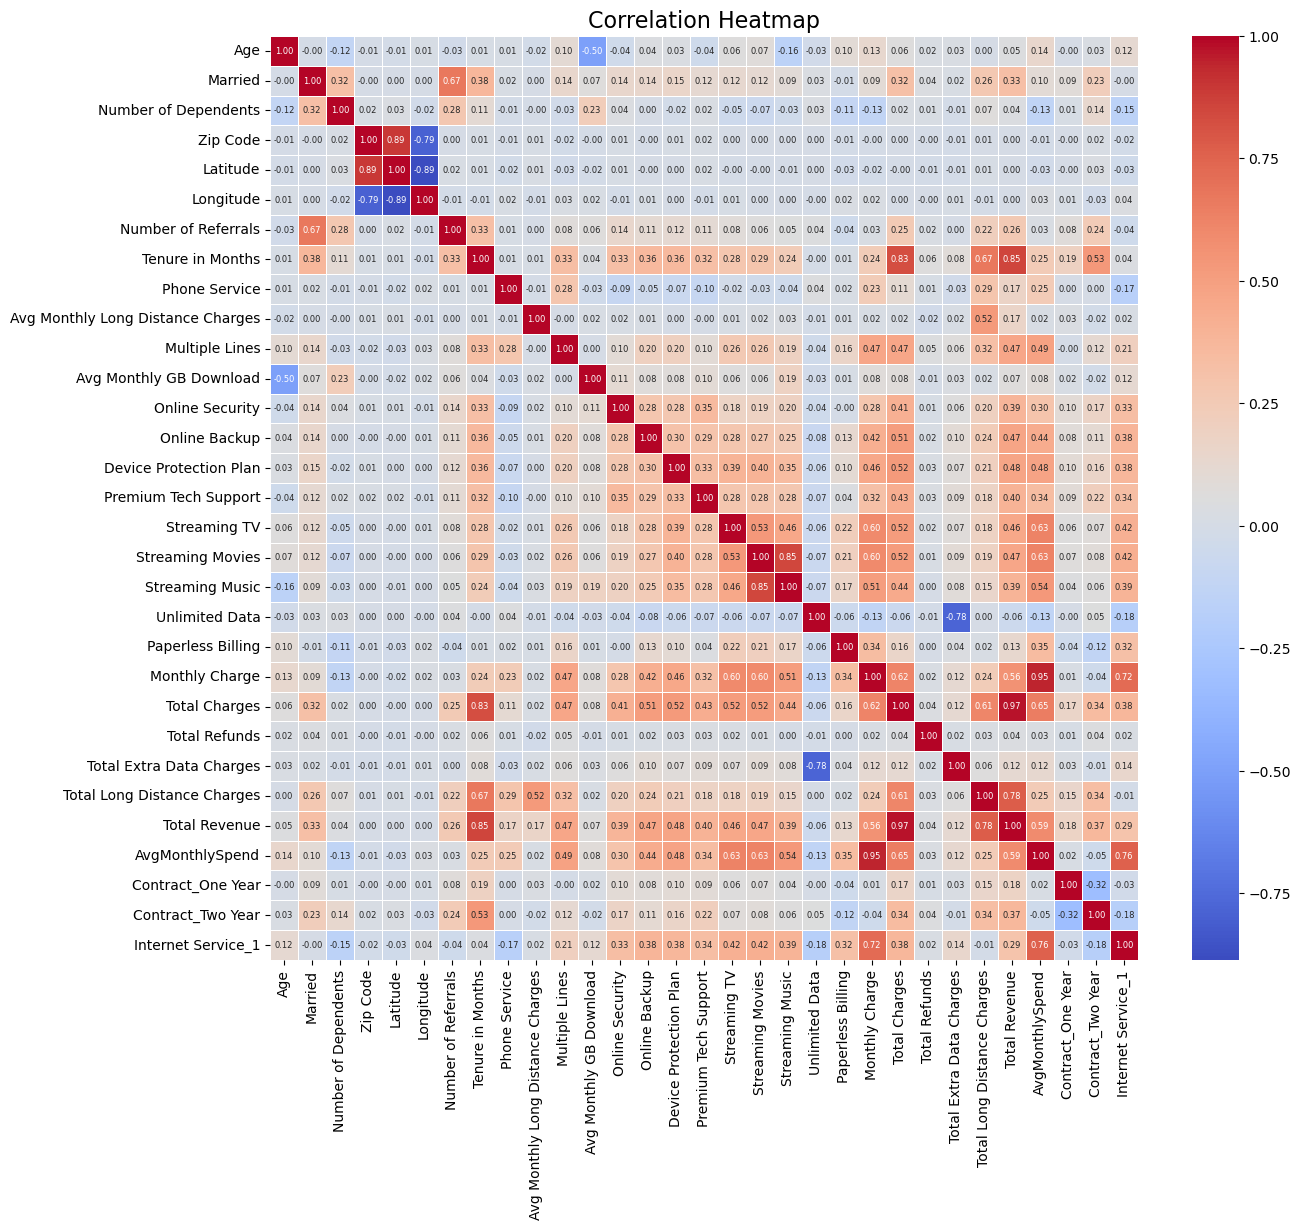

In [41]:
plt.figure(figsize=(14,12))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5,
    annot_kws={"size":6})
plt.title("Correlation Heatmap", fontsize = 16)
plt.show()

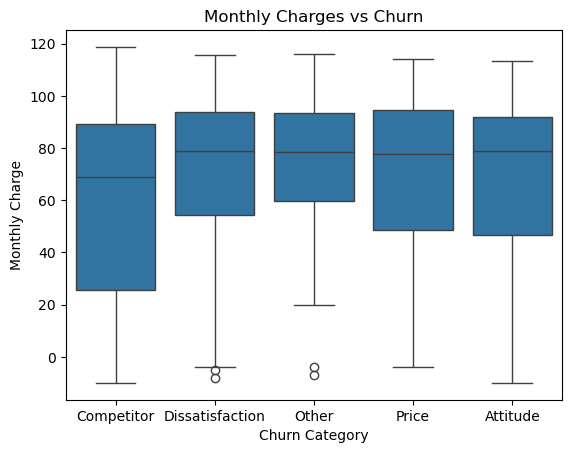

In [45]:
sns.boxplot(x='Churn Category', y='Monthly Charge', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()